In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [28]:
BASE_DIR = os.path.dirname(os.getcwd())
print(BASE_DIR)

dataset_path = os.path.join(
    BASE_DIR,
    "aqua farm ml datasets",
    "fish life.csv"
)
print(dataset_path)

dataset = pd.read_csv(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\aqua farm ml datasets\fish life.csv


In [29]:
dataset

,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),pressure,tempC,humidity,windspeedKmph,label
0,01-02-2022,08:00:00,112.1,7.7,0.002,24.35,1.9,21.3,2.01,1012.0,27.0,21.0,4.0,0.0
1,01-02-2022,08:20:00,119.8,7.6,0.088,24.30,0.8,31.0,1.00,1012.0,30.0,19.0,4.0,0.0
2,01-02-2022,08:40:00,127.4,8.5,0.029,24.28,2.6,27.4,2.45,1012.0,33.0,16.0,4.0,0.0
3,01-02-2022,09:00:00,105.0,7.5,0.060,24.25,2.9,21.9,1.83,1011.0,37.0,13.0,4.0,0.0
4,01-02-2022,09:20:00,121.1,7.4,0.001,24.10,1.3,22.7,1.69,1010.0,37.0,12.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
dataset = dataset.dropna(subset=['label'])

In [31]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74758 entries, 0 to 74757
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             74758 non-null  object 
 1   Time             74707 non-null  object 
 2   NITRATE(PPM)     74758 non-null  float64
 3   PH               74758 non-null  float64
 4   AMMONIA(mg/l)    74758 non-null  float64
 5   TEMP             74758 non-null  float64
 6   DO               74758 non-null  float64
 7   TURBIDITY        74758 non-null  float64
 8   MANGANESE(mg/l)  74758 non-null  float64
 9   pressure         74758 non-null  float64
 10  tempC            74758 non-null  float64
 11  humidity         74758 non-null  float64
 12  windspeedKmph    74758 non-null  float64
 13  label            74758 non-null  float64
dtypes: float64(12), object(2)
memory usage: 8.6+ MB


In [32]:
print(pd.isnull(dataset).sum())

Date                0
Time               51
NITRATE(PPM)        0
PH                  0
AMMONIA(mg/l)       0
TEMP                0
DO                  0
TURBIDITY           0
MANGANESE(mg/l)     0
pressure            0
tempC               0
humidity            0
windspeedKmph       0
label               0
dtype: int64


In [33]:
dataset.describe()

,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),pressure,tempC,humidity,windspeedKmph,label
count,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000
mean,38.699076,6.542758,0.096194,27.226410,10.762849,31.594800,0.981192,1008.148051,27.693250,46.384681,8.761310,0.732310
std,35.769739,1.109403,0.159897,5.973970,5.510198,11.633713,0.771493,5.645551,6.909254,26.480305,4.252619,0.442758
min,0.000000,4.500120,0.000998,0.000000,0.000000,10.200000,0.200000,993.000000,8.000000,3.000000,0.000000,0.000000
25%,16.008650,5.700000,0.029610,22.920839,6.567270,22.864650,0.554393,1003.000000,23.000000,24.000000,6.000000,0.000000
50%,27.552100,6.400000,0.044810,26.819350,9.100750,30.090000,0.705740,1008.000000,27.000000,42.000000,8.000000,1.000000
75%,39.502668,7.301400,0.103184,30.430600,14.992197,37.282975,0.956070,1013.000000,32.000000,68.000000,11.000000,1.000000
max,153.395200,9.006800,1.872000,45.499500,25.497590,82.092240,3.576160,1022.000000,49.000000,100.000000,37.000000,1.000000


In [34]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 0


In [35]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (74758, 14)


In [36]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

Date                object
Time                object
NITRATE(PPM)       float64
PH                 float64
AMMONIA(mg/l)      float64
TEMP               float64
DO                 float64
TURBIDITY          float64
MANGANESE(mg/l)    float64
pressure           float64
tempC              float64
humidity           float64
windspeedKmph      float64
label              float64
dtype: object


In [37]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)


Index(['NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY',
       'MANGANESE(mg/l)', 'pressure', 'tempC', 'humidity', 'windspeedKmph',
       'label'],
      dtype='object')


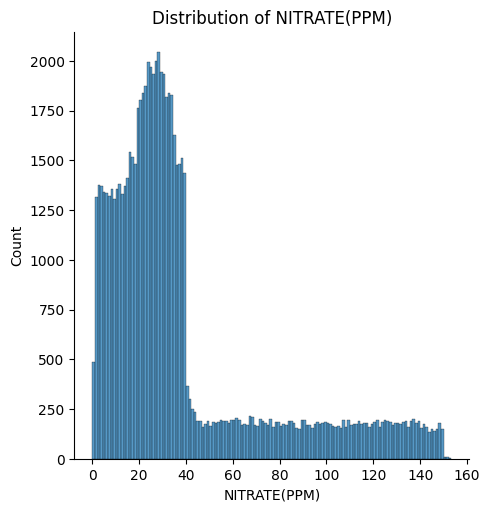

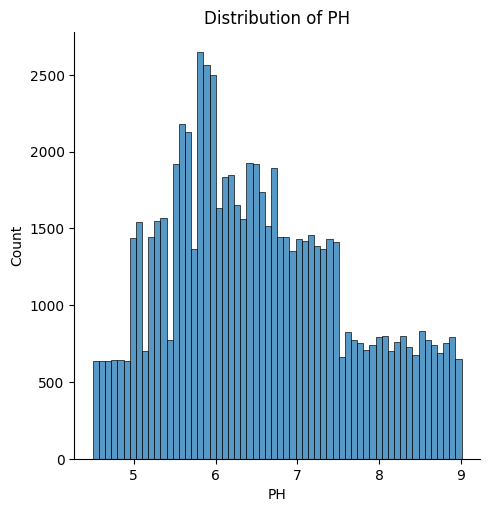

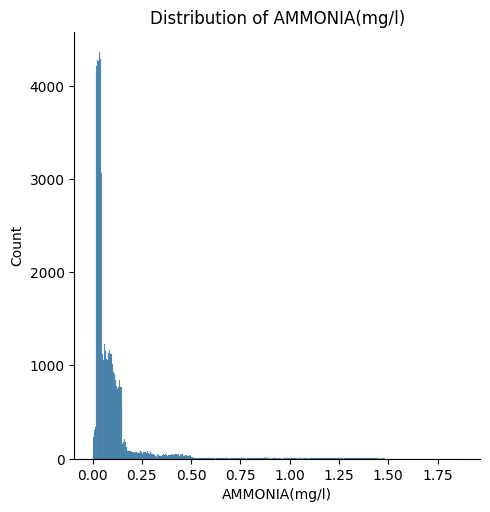

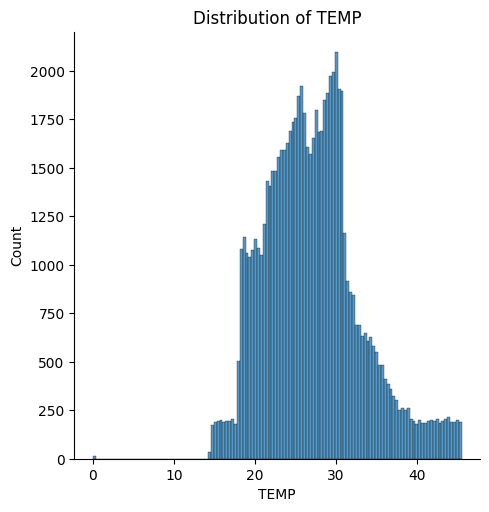

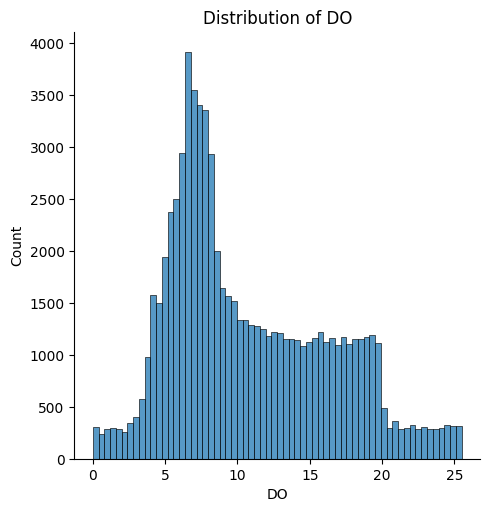

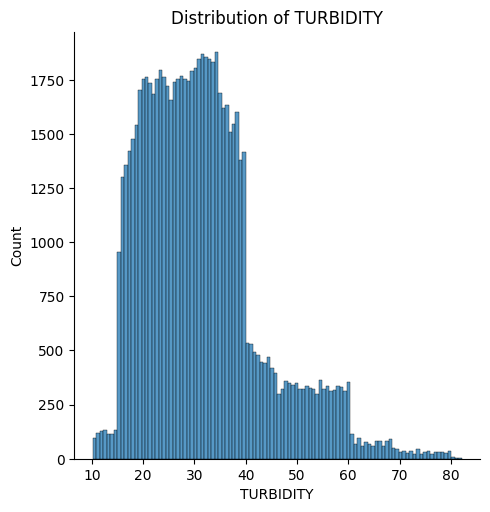

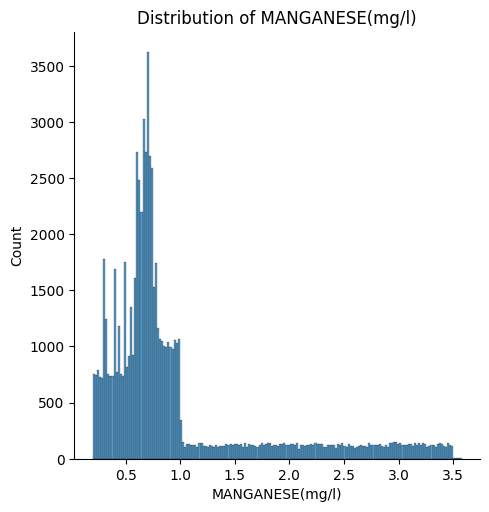

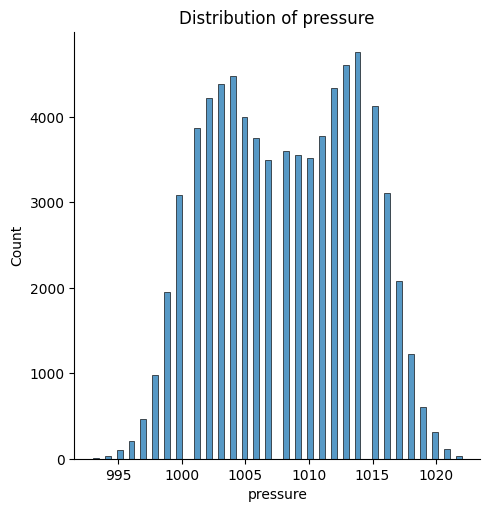

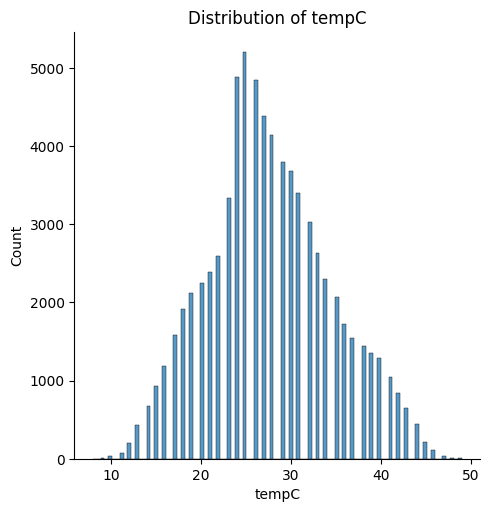

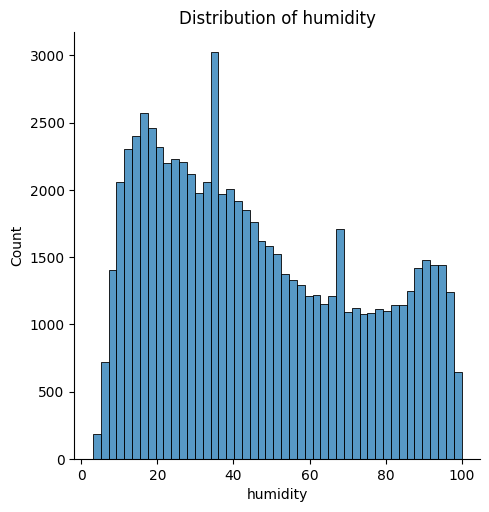

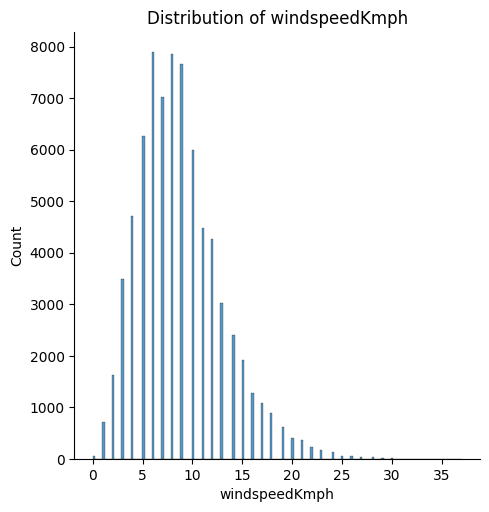

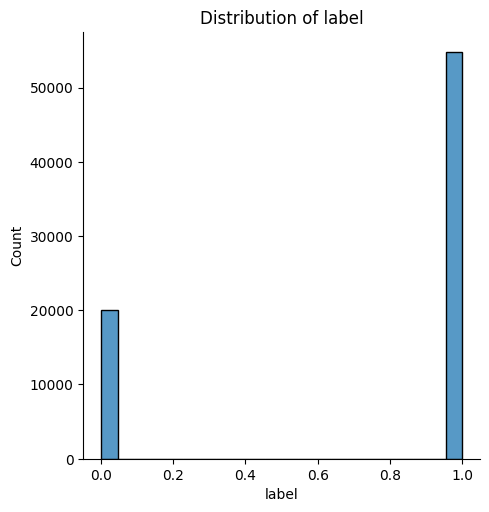

In [38]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [39]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index(['Date', 'Time'], dtype='object')


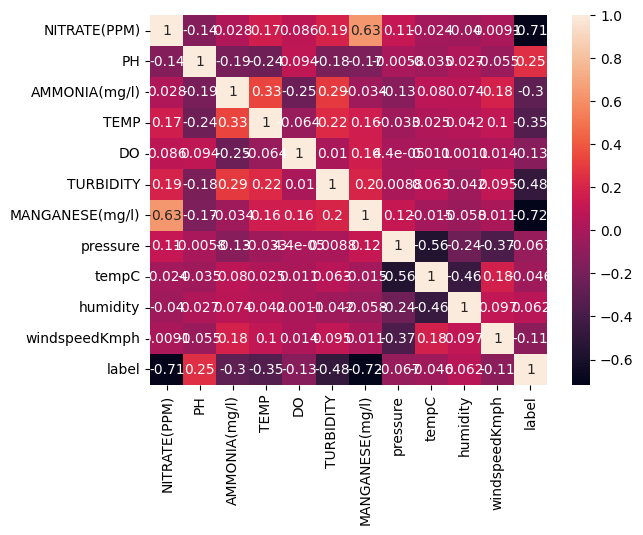

In [40]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [41]:
x = dataset.drop(['Date','Time','label'], axis=1)

In [42]:
x

,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),pressure,tempC,humidity,windspeedKmph
0,112.10000,7.70000,0.002000,24.35000,1.90000,21.30000,2.010000,1012.0,27.0,21.0,4.0
1,119.80000,7.60000,0.088000,24.30000,0.80000,31.00000,1.000000,1012.0,30.0,19.0,4.0
2,127.40000,8.50000,0.029000,24.28000,2.60000,27.40000,2.450000,1012.0,33.0,16.0,4.0
3,105.00000,7.50000,0.060000,24.25000,2.90000,21.90000,1.830000,1011.0,37.0,13.0,4.0
4,121.10000,7.40000,0.001000,24.10000,1.30000,22.70000,1.690000,1010.0,37.0,12.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
74753,34.47580,5.43202,0.054023,23.25975,14.54672,17.21850,0.759367,1003.0,25.0,83.0,16.0
74754,34.18323,6.15657,0.146757,20.21007,23.46253,16.45933,1.860006,1003.0,25.0,85.0,15.0
74755,67.96869,5.63154,0.054299,20.35273,16.66173,18.19536,1.225881,1003.0,27.0,77.0,23.0
74756,38.54060,6.75828,0.119381,15.56445,6.44569,18.46460,2.852199,1002.0,25.0,86.0,18.0


In [43]:
y = dataset['label']

In [44]:
y

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
74753    1.0
74754    1.0
74755    1.0
74756    1.0
74757    1.0
Name: label, Length: 74758, dtype: float64

In [45]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
x_train

,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),pressure,tempC,humidity,windspeedKmph
29892,27.30720,6.92320,0.039690,19.54860,13.83040,27.10740,0.844260,1010.0,39.0,15.0,12.0
44053,71.40000,6.26200,0.082361,22.64856,4.95100,33.44760,0.843200,1010.0,29.0,31.0,8.0
36977,21.64400,5.68970,0.022200,24.92570,15.75390,39.17270,0.582700,1013.0,17.0,48.0,4.0
38129,3.69860,7.77660,0.023220,26.51120,15.30170,24.50700,0.547970,1012.0,25.0,36.0,11.0
31904,24.77470,8.13230,0.040760,18.73050,5.55490,35.13320,0.639730,1005.0,39.0,27.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
37194,7.27510,7.95050,0.034780,28.01960,8.57010,37.94950,0.863340,1013.0,15.0,32.0,4.0
6265,121.60361,4.84195,0.058721,34.40843,13.91286,20.63672,2.160869,1011.0,31.0,32.0,8.0
54886,24.99150,7.76840,0.015650,21.96570,12.72880,15.07660,0.524410,1013.0,31.0,28.0,6.0
860,126.68400,7.69120,0.028930,24.37908,0.70686,25.54740,1.180480,1012.0,17.0,44.0,8.0


In [47]:
x_test

,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),pressure,tempC,humidity,windspeedKmph
56783,31.085700,5.96030,0.036960,22.760900,7.396500,38.813700,0.513090,1002.0,44.0,9.0,9.0
42960,24.564500,7.76410,0.020440,27.466100,11.570700,19.660400,0.699610,1003.0,23.0,91.0,7.0
2195,34.474972,4.50081,0.060393,31.804923,7.442604,54.208525,0.614292,1010.0,32.0,19.0,13.0
69686,31.336448,4.56454,0.114274,28.121203,7.858750,29.027160,0.634768,1015.0,30.0,18.0,3.0
44082,32.640000,6.16100,0.052229,23.083720,4.356880,32.934600,0.763840,1012.0,21.0,45.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...
18234,32.149250,6.73979,0.092261,20.616910,8.230680,56.972280,2.710211,1003.0,39.0,8.0,21.0
70872,16.106496,5.62394,0.048115,25.274245,6.804356,37.456440,0.737150,1015.0,16.0,35.0,11.0
4221,28.041600,5.53377,0.413308,37.161865,6.231572,40.501260,0.331002,1006.0,33.0,53.0,12.0
57299,26.261700,6.43750,0.043800,29.799800,7.405800,18.453600,0.452620,1001.0,37.0,13.0,17.0


In [48]:
y_train

29892    1.0
44053    1.0
36977    1.0
38129    1.0
31904    1.0
        ... 
37194    1.0
6265     0.0
54886    1.0
860      0.0
15795    0.0
Name: label, Length: 59806, dtype: float64

In [49]:
y_test

56783    1.0
42960    1.0
2195     0.0
69686    1.0
44082    1.0
        ... 
18234    0.0
70872    1.0
4221     0.0
57299    1.0
13759    0.0
Name: label, Length: 14952, dtype: float64

In [50]:
print(pd.isnull(x_train).sum())

NITRATE(PPM)       0
PH                 0
AMMONIA(mg/l)      0
TEMP               0
DO                 0
TURBIDITY          0
MANGANESE(mg/l)    0
pressure           0
tempC              0
humidity           0
windspeedKmph      0
dtype: int64


In [51]:
print(pd.isnull(x_test).sum())

NITRATE(PPM)       0
PH                 0
AMMONIA(mg/l)      0
TEMP               0
DO                 0
TURBIDITY          0
MANGANESE(mg/l)    0
pressure           0
tempC              0
humidity           0
windspeedKmph      0
dtype: int64


In [52]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [53]:
x_train

array([[-0.32047613,  0.34474164, -0.35428313, ...,  1.6304312 ,
        -1.18302904,  0.75497876],
       [ 0.908999  , -0.25120099, -0.08795538, ...,  0.18667062,
        -0.57831813, -0.18231515],
       [-0.4783877 , -0.76701764, -0.46344613, ..., -1.54584207,
         0.06418721, -1.11960907],
       ...,
       [-0.38504666,  1.10652432, -0.50432764, ...,  0.47542273,
        -0.69170142, -0.65096211],
       [ 2.45052739,  1.03694361, -0.42143866, ..., -1.54584207,
        -0.08699051, -0.18231515],
       [ 1.6400349 , -0.97538125, -0.14450169, ..., -1.97897025,
         0.21536494, -0.41663863]], shape=(59806, 11))

In [54]:
x_test

array([[-0.21511716, -0.5231246 , -0.3713223 , ...,  2.35231148,
        -1.40979563,  0.05200832],
       [-0.39695304,  1.10264871, -0.47443109, ..., -0.67958573,
         1.68934778, -0.41663863],
       [-0.12061135, -1.83856972, -0.22506947, ...,  0.61979879,
        -1.03185131,  0.98930224],
       ...,
       [-0.29999826, -0.90755807,  1.97763572, ...,  0.76417485,
         0.25315937,  0.75497876],
       [-0.34962865, -0.09302203, -0.32863077, ...,  1.34167908,
        -1.2586179 ,  1.92659615],
       [ 1.72929878, -1.63930027, -0.06118454, ..., -0.39083361,
         1.65155335,  0.05200832]], shape=(14952, 11))

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [56]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }

In [57]:
trained_models = {}
for model_name, model in models.items():
    print(f'---------- Training {model_name} --------------')
    trained_models[model_name] = model.fit(x_train, y_train)
    print('-------------------------------------------------')

---------- Training Logistic Regression --------------
-------------------------------------------------
---------- Training Decision Tree --------------
-------------------------------------------------
---------- Training Random Forest --------------
-------------------------------------------------
---------- Training SVM --------------
-------------------------------------------------
---------- Training KNN --------------
-------------------------------------------------


In [58]:
test_models = {}
for model_name, model in models.items():
    print(f'----------- Testing {model_name} ----------')
    test_models[model_name] = model.predict(x_test)
    print('------------------------------------------')

----------- Testing Logistic Regression ----------
------------------------------------------
----------- Testing Decision Tree ----------
------------------------------------------
----------- Testing Random Forest ----------
------------------------------------------
----------- Testing SVM ----------
------------------------------------------
----------- Testing KNN ----------
------------------------------------------


In [59]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)
    training_results[model_name] = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1': f1_score(y_train, y_train_pred, average='weighted'),
        'precision': precision_score(y_train, y_train_pred, average='weighted')
    }
for i in training_results:
    print(i, training_results[i])

Logistic Regression {'accuracy': 0.999598702471324, 'recall': 0.999598702471324, 'f1': 0.9995987577525254, 'precision': 0.9995989523382494}
Decision Tree {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
Random Forest {'accuracy': 0.9991305220212019, 'recall': 0.9991305220212019, 'f1': 0.9991309148682248, 'precision': 0.9991328086632384}
SVM {'accuracy': 0.9975922148279437, 'recall': 0.9975922148279437, 'f1': 0.9975934441980089, 'precision': 0.9975965865987542}
KNN {'accuracy': 0.9901849312777982, 'recall': 0.9901849312777982, 'f1': 0.9901852211885005, 'precision': 0.9901855174054784}


In [60]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

testing_results = {}

for model_name, model in trained_models.items():

    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted')
    }

for i in testing_results:
    print(i, testing_results[i])

Logistic Regression {'accuracy': 0.9992643124665597, 'recall': 0.9992643124665597, 'f1': 0.9992644616601465, 'precision': 0.9992648980160981}
Decision Tree {'accuracy': 0.9807383627608347, 'recall': 0.9807383627608347, 'f1': 0.9807446084370981, 'precision': 0.9807515674822284}
Random Forest {'accuracy': 0.9854868913857678, 'recall': 0.9854868913857678, 'f1': 0.9855585273285066, 'precision': 0.9858025303129868}
SVM {'accuracy': 0.9963215623327983, 'recall': 0.9963215623327983, 'f1': 0.9963240918471246, 'precision': 0.9963299192206769}
KNN {'accuracy': 0.9840823970037453, 'recall': 0.9840823970037453, 'f1': 0.9840746203721528, 'precision': 0.9840684626392604}


In [61]:
final_model = trained_models['Random Forest']

In [62]:
y_pred = final_model.predict(x_test)

In [63]:
y_pred

array([1., 1., 0., ..., 0., 1., 0.], shape=(14952,))

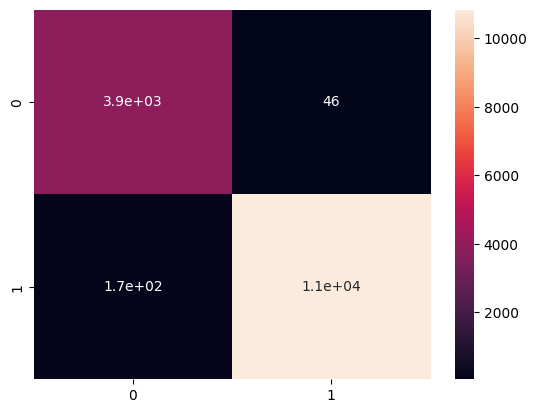

In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [65]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      3948
         1.0       1.00      0.98      0.99     11004

    accuracy                           0.99     14952
   macro avg       0.98      0.99      0.98     14952
weighted avg       0.99      0.99      0.99     14952



In [66]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(estimator=final_model, X=x_train, y=y_train, cv=10)
print(cv.std())
print(cv.mean())

0.00175574284347758
0.9834965937285236


In [67]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy of the model is {round(accuracy, 2)*100}')

The accuracy of the model is 99.0


In [68]:
best_model = trained_models['Random Forest']
jb.dump(best_model, 'fish_life_model.joblib')

['fish_life_model.joblib']

In [69]:
jb.dump(sc, 'fish_life_scaler.joblib')

['fish_life_scaler.joblib']